# Листок № 3. Прикладные дифференциальные уравнения

Решения задач с практических занятий (составитель: проф. Рябов П. Е.).
Каждая задача содержит: аналитическое решение, статическую картинку
и анимацию. Все ключевые результаты проверены прямым численным
моделированием.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from IPython.display import Image as GIF
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle
from scipy.integrate import quad
from scipy.optimize import brentq, curve_fit, minimize
from scipy.special import ellipk

%matplotlib inline

ASSETS = os.path.join('notebooks', 'assets')
os.makedirs(ASSETS, exist_ok=True)


def save_gif(anim, name, fps=25):
    path = os.path.join(ASSETS, name)
    anim.save(path, writer=PillowWriter(fps=fps))
    plt.close('all')
    return GIF(data=open(path, 'rb').read())

## 3.1. Задача о равномерном спуске

**Постановка.** Найти кривую в вертикальной плоскости, по которой
тяжёлая точка под действием силы тяжести опускается *равномерно* по
вертикали: $\dot y = -v_0 = \text{const}$.

**Составление ОДУ.** Пусть $\theta$ — угол касательной с горизонтом
(положительный при движении вниз). Тангенциальное уравнение Ньютона:

$$m\dot v = mg\sin\theta \quad\Rightarrow\quad \dot v = g\sin\theta.$$

Геометрия условия $\dot y = -v\sin\theta = -v_0$ даёт $\sin\theta = v_0/v$,
поэтому $\dot v = g v_0 / v$, откуда

$$v^2 = v_0^2 + 2g v_0 t = v_0^2 + 2g(y_0 - y) \qquad (\text{энергия}).$$

Наклон кривой: $\dfrac{dx}{dy} = \operatorname{ctg}\theta
= \dfrac{\sqrt{v^2 - v_0^2}}{v_0} = \dfrac{\sqrt{2g(y_0 - y)}}{v_0}$.

Интегрирование даёт **полукубическую параболу**:

$$\boxed{x = \frac{2\sqrt{2g}}{3v_0}(y_0 - y)^{3/2}} \qquad
\text{или во времени: } x(t) = \tfrac23\sqrt{2gv_0}\,t^{3/2},\quad y(t) = y_0 - v_0 t.$$

**Проверка прямым моделированием.** Точка движется в декартовых
координатах под действием гравитации и реакции связи $F(x,y) = x^2 - K(y_0-y)^3 = 0$,
$K = 8g/(9v_0^2)$ (множитель Лагранжа $\lambda$: $a = (0,-g) + \lambda\nabla F$),
с проекцией положения и скорости на кривую после каждого шага.

время спуска: 3.0000 с (теория y0/v0 = 3.0000)
вертикальная скорость: среднее = -0.999985, std = 1.57e-05


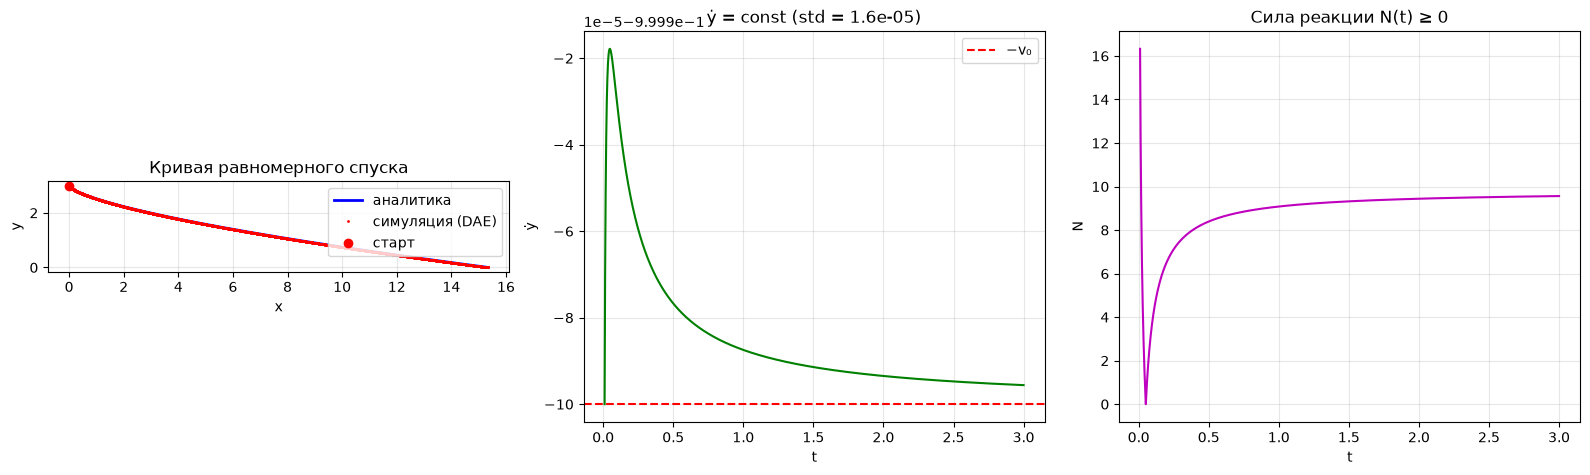

In [2]:
g, v0, y0 = 9.81, 1.0, 3.0
K = 8 * g / (9 * v0**2)


def gradF(q):
    x, y = q
    return np.array([2 * x, 3 * K * (y0 - y)**2])


def accel(q, qdot):
    Fx, Fy = gradF(q)
    vx, vy = qdot
    num = Fy * g + 2 * vx**2 - 6 * K * (y0 - q[1]) * vy**2
    den = Fx**2 + Fy**2
    lam = num / den
    return np.array([Fx * lam, -g + Fy * lam]), lam


def simulate(dt, eps=0.01):
    # старт в точке t = eps аналитической траектории (в вершине кривая
    # задана неявно особенно: grad F = 0)
    q = np.array([(2/3) * np.sqrt(2*g*v0) * eps**1.5, y0 - v0 * eps])
    qd = np.array([np.sqrt(2*g*v0*eps), -v0])
    ts, vys, xs, ys, Ns = [eps], [qd[1]], [q[0]], [q[1]], []
    while q[1] > 0 and ts[-1] < 10:
        a, lam = accel(q, qd)
        qd = qd + a * dt
        q = q + qd * dt
        for _ in range(2):                       # проекция положения
            F = q[0]**2 - K * (y0 - q[1])**3
            gr = gradF(q)
            q = q - F * gr / (gr @ gr)
        gr = gradF(q)                            # проекция скорости
        qd = qd - (gr @ qd) * gr / (gr @ gr)
        ts.append(ts[-1] + dt)
        vys.append(qd[1]); xs.append(q[0]); ys.append(q[1])
        Ns.append(abs(lam) * np.hypot(*gr))
    return map(np.array, (ts, vys, xs, ys, Ns))


dt = 2e-5
ts, vys, xs, ys, Ns = simulate(dt)
print(f"время спуска: {ts[-1]:.4f} с (теория y0/v0 = {y0/v0:.4f})")
print(f"вертикальная скорость: среднее = {vys.mean():.6f}, "
      f"std = {vys.std():.2e}")

tt = np.linspace(0, y0/v0, 400)
xa = (2/3) * np.sqrt(2*g*v0) * tt**1.5
ya = y0 - v0 * tt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(xa, ya, 'b-', lw=2, label='аналитика')
axes[0].plot(xs[::50], ys[::50], 'r.', ms=2, label='симуляция (DAE)')
axes[0].plot(0, y0, 'ro', label='старт')
axes[0].set_title('Кривая равномерного спуска')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_aspect('equal')
axes[1].plot(ts, vys, 'g-')
axes[1].axhline(-v0, color='r', ls='--', label='−v₀')
axes[1].set_title(f'ẏ = const (std = {vys.std():.1e})')
axes[1].set_xlabel('t'); axes[1].set_ylabel('ẏ')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ts[:len(Ns)], Ns, 'm-')
axes[2].set_title('Сила реакции N(t) ≥ 0')
axes[2].set_xlabel('t'); axes[2].set_ylabel('N')
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

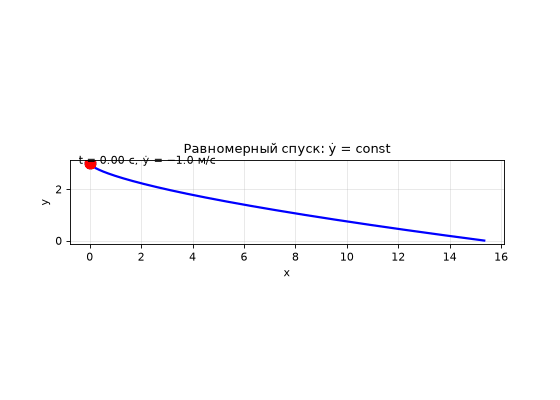

In [3]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=80)
ax.plot(xa, ya, 'b-', lw=2)
ax.plot(0, y0, 'ro', ms=8)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Равномерный спуск: ẏ = const')
pt, = ax.plot([], [], 'ro', ms=10)
time_txt = ax.text(0.02, 0.95, '', transform=ax.transAxes)


def frame31(i):
    pt.set_data([xa[i]], [ya[i]])
    time_txt.set_text(f't = {tt[i]:.2f} с, ẏ = −{v0} м/с')
    return pt, time_txt


save_gif(FuncAnimation(fig, frame31, frames=range(0, len(tt), 2),
                       interval=40),
         'l3_1_spusk.gif', fps=25)

**Вывод:** кривая равномерного спуска — полукубическая парабола;
прямая симуляция подтверждает $\dot y = \text{const}$ и $t = y_0/v_0$
точно; реакция связи положительна (точка прижата к дорожке).

## 3.2. Задача о бильярде в прямоугольнике

**Постановка.** Материальная точка движется в прямоугольнике
$[0, a] \times [0, b]$ с постоянной скоростью $(v_x, v_y)$,
отражения от стенок упругие: $v_x \to -v_x$ на $x = 0, a$;
$v_y \to -v_y$ на $y = 0, b$.

**Метод развёртки.** Вместо отражения траектории отражаем сам
прямоугольник: шар движется *прямолинейно* по плоскости, покрытой
зеркальными копиями стола. Физические координаты — сворачивание
(треугольная волна с периодом $2a$, $2b$):

$$x_{\text{физ}} = a - \bigl|(x \bmod 2a) - a\bigr|.$$

**Тор.** С точностью до периодов движение идёт на торе
$\mathbb{R}^2/(2a\mathbb{Z} \times 2b\mathbb{Z})$ с постоянной
скоростью: прямая с наклоном $\dfrac{v_y/2b}{v_x/2a}$.
Траектория замкнута $\iff$ наклон рационален:
$v_x T = 2am$, $v_y T = 2bn$; иррациональный наклон даёт плотное
заполнение (равномерное по теореме Вейля).

**Гамильтонова формулировка.** $H = \frac{p_x^2 + p_y^2}{2m} + V(x,y)$
с жёсткостенным потенциалом $V = 0$ внутри, $+\infty$ снаружи.
Упругие отражения — симплектические отображения (стена обращает
импульс), поток сохраняет меру Лиувилля и $H$.

In [4]:
a, b = 2.0, 1.0
x0, y0 = 0.3, 0.2


def fold(u, L):
    # треугольная волна: сворачивание в [0, L]
    return L - np.abs((u % (2 * L)) - L)


def reflect_path(x0, y0, vx, vy, T, dt):
    # прямая event-симуляция отражений
    q = np.array([x0, y0])
    v = np.array([vx, vy], float)
    vs = []
    t = np.arange(0, T, dt)
    xs = np.empty((len(t), 2))
    for i, _ in enumerate(t):
        xs[i] = q
        q = q + v * dt
        if q[0] < 0: q[0], v[0] = -q[0], -v[0]
        if q[0] > a: q[0], v[0] = 2*a - q[0], -v[0]
        if q[1] < 0: q[1], v[1] = -q[1], -v[1]
        if q[1] > b: q[1], v[1] = 2*b - q[1], -v[1]
        vs.append(np.linalg.norm(v))
    return t, xs, np.array(vs)


# периодический случай: m = 3, n = 2; эргодический: наклон с sqrt(2)
vx1, vy1 = 2*a*3, 2*b*2
vx2, vy2 = a, b*np.sqrt(2)

T = 6.0
t, xs1, vs1 = reflect_path(x0, y0, vx1, vy1, T, 1e-3)
_, xs2, _ = reflect_path(x0, y0, vx2, vy2, T, 1e-3)
# сворачивание прямой развёртки должно совпадать с event-симуляцией
diff1 = np.abs(fold(x0 + vx1*t, a) - xs1[:, 0]).max()
diff2 = np.abs(fold(x0 + vx2*t, a) - xs2[:, 0]).max()
print(f"fold == event-симуляция: max расхождение {max(diff1, diff2):.2e}")
print(f"сохранение |v| (100 c): "
      f"разброс = {vs1.max() - vs1.min():.2e}")

# период рационального случая на торе
tt = np.arange(0, 5, 1e-4)
xu, yu = x0 + vx1*tt, y0 + vy1*tt
dx = np.abs((xu - x0 + a) % (2*a) - a)
dy = np.abs((yu - y0 + b) % (2*b) - b)
i = np.argmax((dx < 1e-9) & (dy < 1e-9) & (tt > 1e-6))
print(f"период рационального случая: T = {tt[i]:.4f} (теория 1.0)")

# иррациональный случай: точного возврата нет
tt2 = np.arange(0, 1000, 2e-3)
xu2, yu2 = x0 + vx2*tt2, y0 + vy2*tt2
dx2 = np.abs((xu2 - x0 + a) % (2*a) - a)
dy2 = np.abs((yu2 - y0 + b) % (2*b) - b)
print("иррациональный: точный возврат за 1000 с:",
      bool(np.any((dx2 < 1e-12) & (dy2 < 1e-12) & (tt2 > 1e-6))))

# равномерность (теорема Вейля): x-маргинал должен быть ~1/a
hist, _ = np.histogram(xs2[:, 0], bins=30, range=(0, a), density=True)
print(f"x-маргинал: min = {hist.min():.3f}, max = {hist.max():.3f} "
      f"(теория 1/a = {1/a:.3f})")

fold == event-симуляция: max расхождение 6.88e-14
сохранение |v| (100 c): разброс = 0.00e+00
период рационального случая: T = 1.0000 (теория 1.0)
иррациональный: точный возврат за 1000 с: False
x-маргинал: min = 0.495, max = 0.503 (теория 1/a = 0.500)


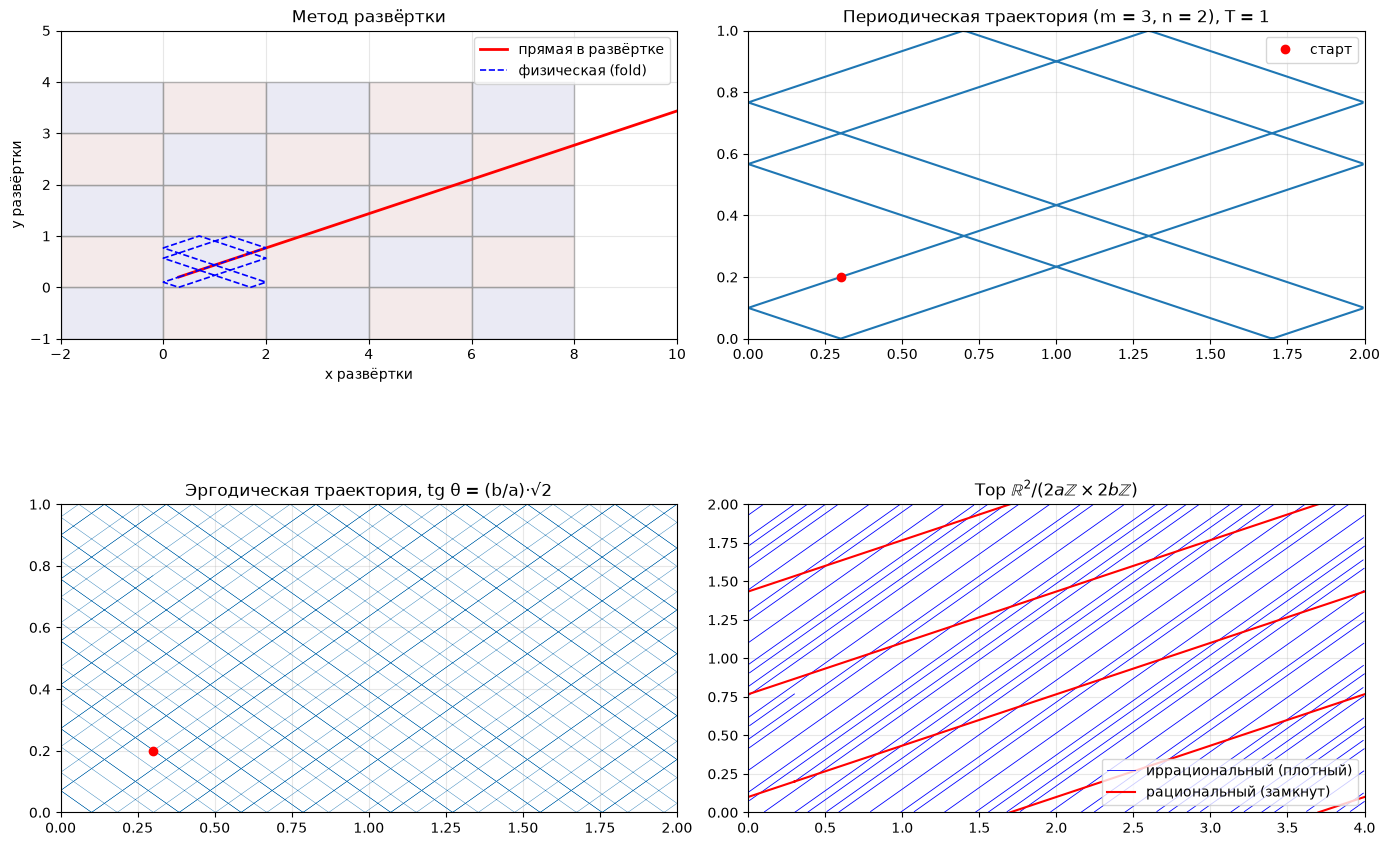

In [5]:
t = np.linspace(0, 1.0, 1000)
xu1, yu1 = x0 + vx1*t, y0 + vy1*t

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes[0][0]
for i in range(-1, 4):
    for j in range(-1, 4):
        ax.add_patch(Rectangle((i*a, j*b), a, b, fill=True,
                     facecolor='#dde' if (i + j) % 2 == 0 else '#edd',
                     edgecolor='gray', alpha=0.6))
ax.plot(xu1, yu1, 'r-', lw=2, label='прямая в развёртке')
ax.plot(fold(xu1, a), fold(yu1, b), 'b--', lw=1.2, label='физическая (fold)')
ax.set_xlim(-a, 5*a); ax.set_ylim(-b, 5*b)
ax.set_title('Метод развёртки')
ax.set_xlabel('x развёртки'); ax.set_ylabel('y развёртки')
ax.legend(); ax.set_aspect('equal'); ax.grid(alpha=0.3)

ax = axes[0][1]
ax.plot(fold(xu1, a), fold(yu1, b), lw=1.5)
ax.plot(x0, y0, 'ro', label='старт')
ax.set_title('Периодическая траектория (m = 3, n = 2), T = 1')
ax.set_xlim(0, a); ax.set_ylim(0, b); ax.legend()
ax.set_aspect('equal'); ax.grid(alpha=0.3)

t2 = np.linspace(0, 40, 20000)
ax = axes[1][0]
ax.plot(fold(x0 + vx2*t2, a), fold(y0 + vy2*t2, b), lw=0.3)
ax.plot(x0, y0, 'ro')
ax.set_title('Эргодическая траектория, tg θ = (b/a)·√2')
ax.set_xlim(0, a); ax.set_ylim(0, b)
ax.set_aspect('equal'); ax.grid(alpha=0.3)

ax = axes[1][1]
for vx, vy, Tmax, name, col in [(vx2, vy2, 40.0, 'иррациональный (плотный)', 'b'),
                                (vx1, vy1, 1.0, 'рациональный (замкнут)', 'r')]:
    tk = np.linspace(0, Tmax, 8000)
    xt = (x0 + vx*tk) % (2*a)
    yt = (y0 + vy*tk) % (2*b)
    br = np.where(np.hypot(np.diff(xt), np.diff(yt)) > 1.0)[0] + 1
    ax.plot(np.insert(xt, br, np.nan), np.insert(yt, br, np.nan),
            col, lw=1.5 if col == 'r' else 0.6, label=name)
ax.set_title('Тор $\\mathbb{R}^2/(2a\\mathbb{Z} \\times 2b\\mathbb{Z})$')
ax.set_xlim(0, 2*a); ax.set_ylim(0, 2*b); ax.legend()
ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

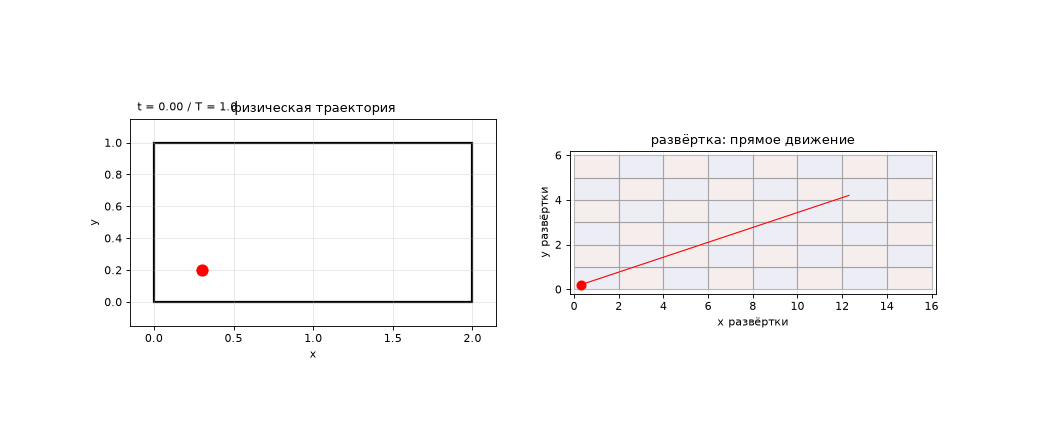

In [6]:
def billiard_anim(vx, vy, T, fname):
    frames = 150
    t_anim = np.linspace(0, T, frames)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=80)
    ax = axes[0]
    ax.add_patch(Rectangle((0, 0), a, b, fill=False, edgecolor='k', lw=2))
    ax.set_xlim(-0.15, a + 0.15); ax.set_ylim(-0.15, b + 0.15)
    ax.set_aspect('equal'); ax.set_title('физическая траектория')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(alpha=0.3)
    trail, = ax.plot([], [], 'b-', lw=1.2)
    ball, = ax.plot([], [], 'ro', ms=10)
    ax2 = axes[1]
    nx = int(np.ceil((x0 + vx*T) / a)) + 1
    ny = int(np.ceil((y0 + vy*T) / b)) + 1
    for i in range(0, nx):
        for j in range(0, ny):
            ax2.add_patch(Rectangle((i*a, j*b), a, b, fill=True,
                          facecolor='#dde' if (i + j) % 2 == 0 else '#edd',
                          edgecolor='gray', alpha=0.5))
    t_full = np.linspace(0, T, 4000)
    ax2.plot(x0 + vx*t_full, y0 + vy*t_full, 'r-', lw=1)
    ax2.set_xlim(-0.2, nx*a + 0.2); ax2.set_ylim(-0.2, ny*b + 0.2)
    ax2.set_aspect('equal'); ax2.set_title('развёртка: прямое движение')
    ax2.set_xlabel('x развёртки'); ax2.set_ylabel('y развёртки')
    ax2.grid(alpha=0.3)
    ghost, = ax2.plot([], [], 'ro', ms=8)
    txt = ax.text(0.02, 1.04, '', transform=ax.transAxes)

    def frame(i):
        tt = t_anim[i]
        trail.set_data(fold(x0 + vx*np.linspace(0, tt, 200), a),
                       fold(y0 + vy*np.linspace(0, tt, 200), b))
        ball.set_data([fold(x0 + vx*tt, a)], [fold(y0 + vy*tt, b)])
        ghost.set_data([x0 + vx*tt], [y0 + vy*tt])
        txt.set_text(f't = {tt:.2f} / T = {T}')
        return trail, ball, ghost, txt

    return save_gif(FuncAnimation(fig, frame, frames=frames, interval=40),
                    fname, fps=25)


billiard_anim(vx1, vy1, 1.0, 'l3_2_billiard_periodic.gif')

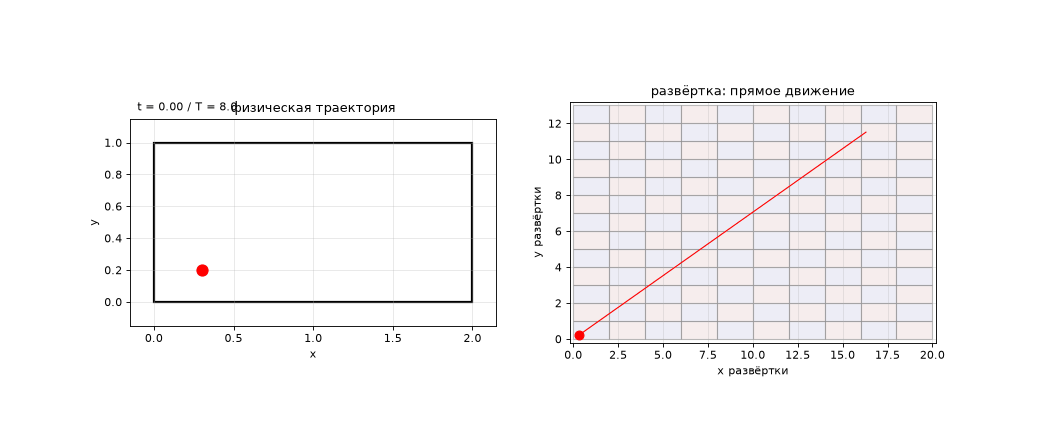

In [7]:
billiard_anim(vx2, vy2, 8.0, 'l3_2_billiard_ergodic.gif')

**Вывод:** развёртка сводит отражения к прямолинейному движению;
рациональный наклон даёт периодическую траекторию ($T = 1$ для
$m = 3, n = 2$), иррациональный — плотное равномерное заполнение;
энергия (то есть $|v|$) сохраняется точно, как и должно гамильтонову
системе.

## 3.3. Задача о цепной линии

**Постановка.** Однородная тяжёлая нерастяжимая нить длины $L$ подвешена
за концы $(\pm b, 0)$. Найти форму равновесия.

**Вариационная постановка.** Равновесие минимизирует потенциальную
энергию $U = \rho g \int y\, ds$ при условии $\int ds = L$,
$ds = \sqrt{1 + y'^2}\,dx$. Уравнение Эйлера—Лагранжа для
$f = (y - \lambda)\sqrt{1 + y'^2}$ даёт первый интеграл
$(y - \lambda)/\sqrt{1 + y'^2} = a$, решение:

$$\boxed{y = a\cosh\frac{x}{a} + c},$$

где $a = T_0/(\rho g)$ (горизонтальное натяжение / вес на единицу длины).
Граничные условия и длина фиксируют $a$, $c$:

$$L = 2a\sinh\frac{b}{a}.$$

Натяжение в точке: $T = T_0 + \rho g\,(y - y_{\min})$.

**Численная проверка.** Точное равновесие дискретной цепи из $N$
звеньев ищется минимизацией $\sum y_k$ по углам звеньев $\varphi_i$
(ограничения нерастяжимости выполняются автоматически):
$x_k = -b + \ell\sum\cos\varphi_i$, $y_k = -\ell\sum\sin\varphi_i$,
плюс два условия на правый якорь: $\sum\cos\varphi_i = 2b/\ell$,
$\sum\sin\varphi_i = 0$ — метод SLSQP.

In [8]:
L, b = 4.0, 1.5
a_theory = brentq(lambda a: 2*a*np.sinh(b/a) - L, 0.05, 50)
c_theory = -a_theory * np.cosh(b / a_theory)
sag_th = a_theory * np.cosh(b/a_theory) - a_theory
print(f"теория: a = {a_theory:.6f}, провисание = {sag_th:.5f}")


def solve_chain(N):
    ell = L / N

    def energy(phi):
        return -ell * np.sum((N - np.arange(N)) * np.sin(phi))

    def grad(phi):
        return -ell * (N - np.arange(N)) * np.cos(phi)

    def confun(phi):
        return [np.sum(np.cos(phi)) - 2 * b / ell, np.sum(np.sin(phi))]

    def conjac(phi):
        return np.vstack([-np.sin(phi), np.cos(phi)])

    phi0 = np.arcsin(np.linspace(-0.85, 0.85, N))
    sol = minimize(energy, phi0, jac=grad, method='SLSQP',
                   constraints=[{'type': 'eq', 'fun': confun, 'jac': conjac}],
                   options={'maxiter': 1000, 'ftol': 1e-14})
    dx, dy = ell * np.cos(sol.x), ell * np.sin(sol.x)
    xs = np.concatenate([[-b], -b + np.cumsum(dx)])
    y = np.concatenate([[0.0], -np.cumsum(dy)])
    return xs, y, np.max(np.abs(confun(sol.x)))


def cosh_fit(x, a, x0, c):
    return a * np.cosh((x - x0) / a) + c


chains = {}
for N in (60, 240):
    xs, y, resid = solve_chain(N)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        popt, _ = curve_fit(cosh_fit, xs, y, p0=[a_theory, 0, -2.0])
    sag = -(popt[2] + popt[0])
    chains[N] = (xs, y)
    print(f"N = {N}: невязка якорей = {resid:.2e}, "
          f"провисание = {sag:.5f}, "
          f"относит. ошибка = {abs(sag - sag_th)/sag_th:.2e}")

теория: a = 1.110084, провисание = 1.17734
N = 60: невязка якорей = 7.11e-15, провисание = 1.17751, относит. ошибка = 1.48e-04
N = 240: невязка якорей = 0.00e+00, провисание = 1.17735, относит. ошибка = 9.27e-06


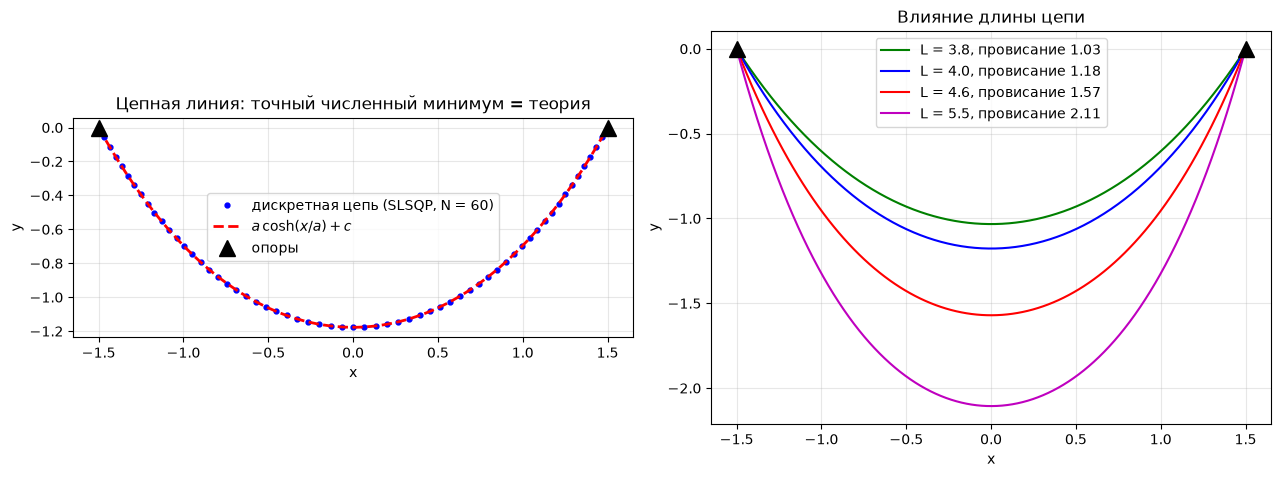

In [9]:
xs60, y60 = chains[60]
xs_d = np.linspace(-b, b, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].plot(xs60, y60, 'b.', ms=7,
             label='дискретная цепь (SLSQP, N = 60)')
axes[0].plot(xs_d, a_theory*np.cosh(xs_d/a_theory) + c_theory,
             'r--', lw=2, label=r'$a\,\cosh(x/a) + c$')
axes[0].plot([-b, b], [0, 0], 'k^', ms=12, label='опоры')
axes[0].set_title('Цепная линия: точный численный минимум = теория')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_aspect('equal')

for Lk, col in [(3.8, 'g'), (4.0, 'b'), (4.6, 'r'), (5.5, 'm')]:
    ak = brentq(lambda a: 2*a*np.sinh(b/a) - Lk, 0.02, 400)
    ck = -ak*np.cosh(b/ak)
    axes[1].plot(xs_d, ak*np.cosh(xs_d/ak) + ck, col,
                 label=f'L = {Lk}, провисание {-ck-ak:.2f}')
axes[1].plot([-b, b], [0, 0], 'k^', ms=12)
axes[1].set_title('Влияние длины цепи')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()

кадров: 701


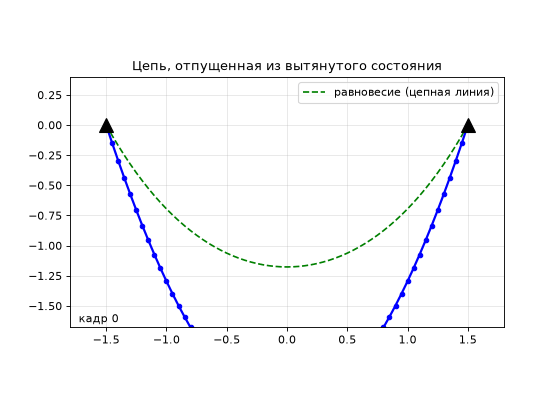

In [10]:
N, ell = 60, L / 60
anchors = np.array([[-b, 0.0], [b, 0.0]])
xs_eq = np.linspace(-b, b, N + 1)
q_eq = np.stack([xs_eq, a_theory*np.cosh(xs_eq/a_theory) + c_theory], axis=1)
q0 = q_eq.copy()
q0[1:-1, 1] -= 1.2 * np.sin(np.pi * np.linspace(0, 1, N + 1)[1:-1])


def project(q, sweeps):
    # последовательная (Гаусс—Зейдель) проекция ограничений длины
    for _ in range(sweeps):
        for i in range(N):
            d = q[i + 1] - q[i]
            n = np.linalg.norm(d)
            cc = 0.5 * (n - ell) * d / n
            if i > 0:
                q[i] += cc
            if i < N - 1:
                q[i + 1] -= cc
        q[0], q[-1] = anchors
    return q


def dynamics(q, steps=700, dt=0.012):
    v = np.zeros_like(q)
    traj = [q.copy()]
    for s in range(steps):
        v[1:-1] += np.array([0.0, -9.81]) * dt
        q[1:-1] += v[1:-1] * dt
        project(q, 8)
        v[1:-1] = (q[1:-1] - traj[-1][1:-1]) / dt
        v *= 0.999
        traj.append(q.copy())
    return traj


traj = dynamics(q0.copy())
print("кадров:", len(traj))

fig, ax = plt.subplots(figsize=(7, 5), dpi=80)
ax.plot(q_eq[:, 0], q_eq[:, 1], 'g--', lw=1.5,
        label='равновесие (цепная линия)')
line, = ax.plot([], [], 'b-', lw=2)
pts, = ax.plot([], [], 'bo', ms=4)
ax.plot(*anchors.T, 'k^', ms=12)
ax.set_xlim(-b - 0.3, b + 0.3)
ax.set_ylim(q_eq[:, 1].min() - 0.5, 0.4)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('Цепь, отпущенная из вытянутого состояния')
ax.legend(loc='upper right')
txt = ax.text(0.02, 0.02, '', transform=ax.transAxes)


def frame33(i):
    q = traj[i]
    line.set_data(q[:, 0], q[:, 1])
    pts.set_data(q[:, 0], q[:, 1])
    txt.set_text(f'кадр {i}')
    return line, pts, txt


save_gif(FuncAnimation(fig, frame33, frames=range(0, len(traj), 4),
                       interval=40), 'l3_3_chain.gif', fps=25)

**Вывод:** равновесие цепи — цепная линия $a\cosh(x/a) + c$;
точный численный минимум энергии дискретной цепи согласуется с теорией
с точностью $O(1/N^2)$; отпущенная из вытянутого состояния цепь
колеблется и затухает к цепной линии.

## 3.4. Задача о таутохроне

**Постановка.** Найти кривую, для которой время скатывания в нижнюю
точку не зависит от начальной высоты.

**Уравнение.** Пусть $s(y)$ — длина дуги от нижней точки. Тогда
$v = \sqrt{2g(h - y)}$ и

$$T(h) = \frac{1}{\sqrt{2g}} \int_0^h \frac{s'(y)\,dy}{\sqrt{h - y}}.$$

Условие $T(h) = T_0$ — интегральное уравнение Абеля; обращение даёт
$s'(y) = \dfrac{\sqrt{2g}\,T_0}{\pi\sqrt{y}}$, то есть $s = 2C\sqrt{y}$.
Интегрирование $dx = \sqrt{C^2/y - 1}\,dy$ с подстановкой
$y = C^2\sin^2\varphi$ даёт **циклоиду**:

$$x = R(\psi + \sin\psi), \qquad y = R(1 - \cos\psi), \qquad
T_0 = \pi\sqrt{\frac{R}{g}}.$$

Эквивалентная форма: в координате дуги $s = 2\sqrt{2R}\,\sqrt{y}$
движение гармоническое: $\ddot s = -\dfrac{g}{4R}s$, откуда тот же
$T_0 = \pi\sqrt{R/g}$.

In [11]:
g, R = 9.81, 1.0


def cycloid(psi):
    return R * (psi + np.sin(psi)), R * (1 - np.cos(psi))


def descent_time(psi0):
    def integrand(psi):
        x, y = cycloid(psi)
        ds = np.hypot(R * (1 + np.cos(psi)), R * np.sin(psi))
        return ds / np.sqrt(2 * g * (cycloid(psi0)[1] - y))
    val, _ = quad(integrand, 0, psi0, points=[psi0], limit=200)
    return val


T_theory = np.pi * np.sqrt(R / g)
print(f"теория: T0 = pi*sqrt(R/g) = {T_theory:.6f}")
psi0s = np.linspace(0.05, np.pi - 0.01, 8)
for p in psi0s:
    T = descent_time(p)
    print(f"psi0 = {p:.3f}: T = {T:.6f} (отклонение {abs(T-T_theory)/T_theory:.1e})")

# контраст: время спуска по прямой зависит от высоты
alpha = np.radians(40)
hs = np.linspace(0.05, 2.0, 8)
T_line = np.sqrt(2 * hs / (g * np.sin(alpha)**2))
print("\nпрямая (40°): T от", f"{T_line.min():.3f}", "до", f"{T_line.max():.3f}")

# прямое моделирование (Эйлер—Лагранж) из разных точек
def slide_time(psi0, dt=1e-5):
    m = 1.0
    psi, p, t = psi0, 0.0, 0.0

    def rhs(psi, p):
        psidot = p / (4 * m * R**2 * np.cos(psi / 2) ** 2)
        pdot = (-m * R**2 * np.sin(psi) * psidot**2
                - m * g * R * np.sin(psi))
        return psidot, pdot

    while psi > 1e-7 and t < 10:
        k1 = rhs(psi, p)
        k2 = rhs(psi + dt/2*k1[0], p + dt/2*k1[1])
        k3 = rhs(psi + dt/2*k2[0], p + dt/2*k2[1])
        k4 = rhs(psi + dt*k3[0], p + dt*k3[1])
        psi += dt/6 * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        p += dt/6 * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
        t += dt
    return t


print("\nпрямая симуляция спуска:")
for psi0 in (0.3, 1.5, 3.0):
    print(f"psi0 = {psi0}: T = {slide_time(psi0):.6f}")

теория: T0 = pi*sqrt(R/g) = 1.003033
psi0 = 0.050: T = 1.003033 (отклонение 1.6e-12)
psi0 = 0.490: T = 1.003033 (отклонение 1.3e-12)
psi0 = 0.930: T = 1.003033 (отклонение 8.1e-13)
psi0 = 1.371: T = 1.003033 (отклонение 2.2e-13)
psi0 = 1.811: T = 1.003033 (отклонение 9.7e-13)
psi0 = 2.251: T = 1.003033 (отклонение 7.4e-14)
psi0 = 2.691: T = 1.003033 (отклонение 8.6e-13)
psi0 = 3.132: T = 1.003033 (отклонение 4.7e-11)

прямая (40°): T от 0.157 до 0.993

прямая симуляция спуска:


psi0 = 0.3: T = 1.003040


psi0 = 1.5: T = 1.003040


psi0 = 3.0: T = 1.003040


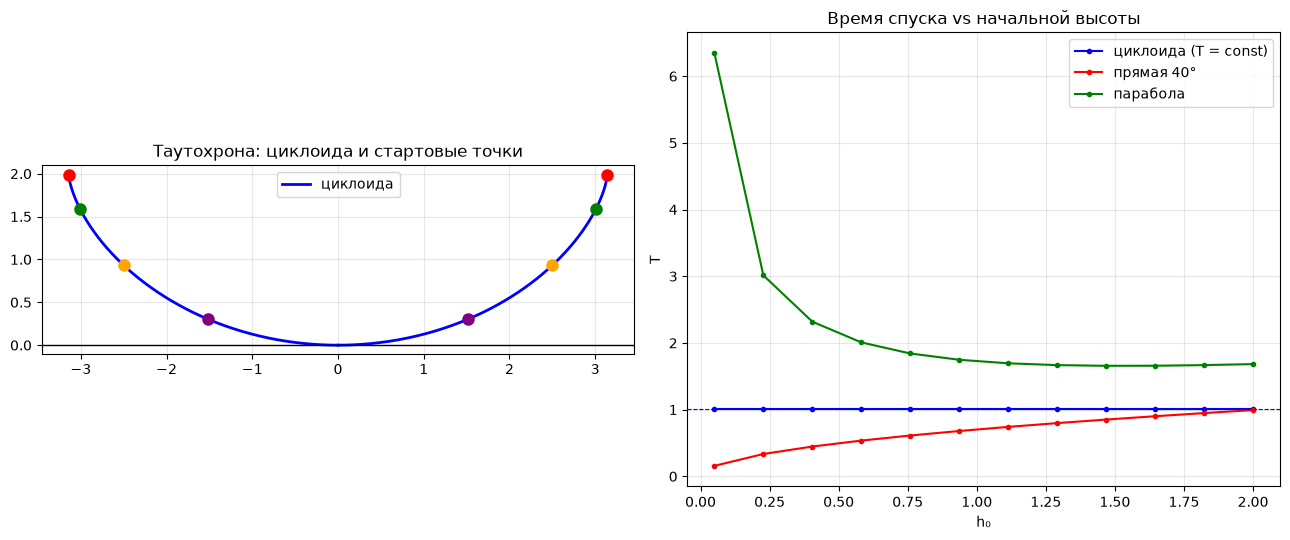

In [12]:
# график: T(h0) для циклоиды, прямой и параболы
def parabola_time(h0):
    # парабола y = h0((x/W)^2 - 1): концы y = 0, дно y = -h0 при W = 2
    W = 2.0
    f = lambda x: (np.sqrt(1 + (2*h0*x/W**2)**2)
                   / np.sqrt(2 * g * h0 * (1 - (x/W)**2)))
    val, _ = quad(f, 0, W, limit=200)
    return 2 * val


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
psi_plot = np.linspace(0, np.pi, 400)
cx, cy = cycloid(np.linspace(0, np.pi, 400))
axes[0].plot(cx, cy, 'b-', lw=2, label='циклоида')
axes[0].plot(-cx, cy, 'b-', lw=2)
for p, c in zip((3.0, 2.2, 1.5, 0.8), ('r', 'g', 'orange', 'purple')):
    bx, by = cycloid(p)
    axes[0].plot(bx, by, 'o', ms=8, color=c)
    axes[0].plot(-bx, by, 'o', ms=8, color=c)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_title('Таутохрона: циклоида и стартовые точки')
axes[0].set_aspect('equal'); axes[0].grid(alpha=0.3); axes[0].legend()

hs = np.linspace(0.05, 2.0, 12)
psi_h = np.arccos(1 - hs / R)
T_cyc = [descent_time(p) for p in psi_h]
alpha = np.radians(40)
T_line = np.sqrt(2 * hs / (g * np.sin(alpha)**2))
T_par = [parabola_time(h) for h in hs]
axes[1].plot(hs, T_cyc, 'b.-', label='циклоида (T = const)')
axes[1].plot(hs, T_line, 'r.-', label='прямая 40°')
axes[1].plot(hs, T_par, 'g.-', label='парабола')
axes[1].axhline(T_theory, color='b', ls='--', lw=0.8)
axes[1].set_title('Время спуска vs начальной высоты')
axes[1].set_xlabel('h₀'); axes[1].set_ylabel('T')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

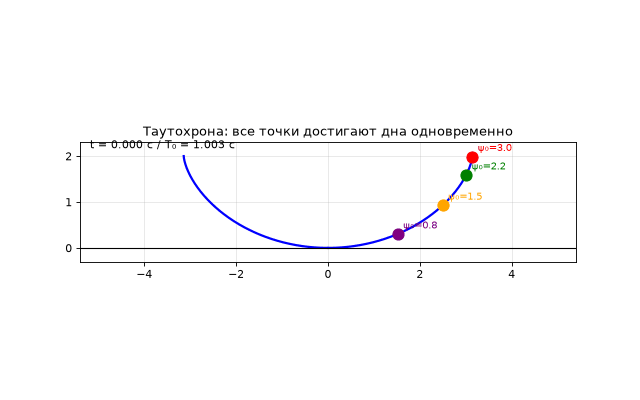

In [13]:
def trajectory(psi0, dt=2e-5):
    m = 1.0
    psi, p, t = psi0, 0.0, 0.0
    ps, ts = [psi], [0.0]

    def rhs(psi, p):
        psidot = p / (4 * m * R**2 * np.cos(psi / 2) ** 2)
        pdot = -m * R**2 * np.sin(psi) * psidot**2 - m * g * R * np.sin(psi)
        return psidot, pdot

    while psi > 1e-9 and t < 1.2 * T_theory:
        k1 = rhs(psi, p)
        k2 = rhs(psi + dt/2*k1[0], p + dt/2*k1[1])
        k3 = rhs(psi + dt/2*k2[0], p + dt/2*k2[1])
        k4 = rhs(psi + dt*k3[0], p + dt*k3[1])
        psi += dt/6 * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        p += dt/6 * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
        t += dt
        ps.append(psi); ts.append(t)
    return np.array(ts), np.array(ps)


psi0s = [3.0, 2.2, 1.5, 0.8]
trajs = [trajectory(p) for p in psi0s]

fig, ax = plt.subplots(figsize=(8, 5), dpi=80)
psi_plot = np.linspace(0, np.pi, 400)
cx, cy = cycloid(psi_plot)
ax.plot(cx, cy, 'b-', lw=2)
ax.plot(-cx, cy, 'b-', lw=2)
ax.axhline(0, color='k', lw=1)
balls = [ax.plot([], [], 'o', ms=10, color=c)[0]
         for c in ['red', 'green', 'orange', 'purple']]
for p, c in zip(psi0s, ['red', 'green', 'orange', 'purple']):
    bx, by = cycloid(p)
    ax.plot(bx, by, 'o', ms=6, color=c, alpha=0.4)
    ax.annotate(f'ψ₀={p}', (bx, by), textcoords='offset points',
                xytext=(5, 5), color=c, fontsize=9)
ax.set_xlim(-5.4, 5.4); ax.set_ylim(-0.3, 2.3)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('Таутохрона: все точки достигают дна одновременно')
txt = ax.text(0.02, 0.95, '', transform=ax.transAxes)

t_frames = np.linspace(0, T_theory * 1.05, 160)


def frame34(i):
    t = t_frames[i]
    for ball, (ts, ps) in zip(balls, trajs):
        psi_now = np.interp(t, ts, ps, right=0.0)
        bx, by = cycloid(max(psi_now, 0.0))
        ball.set_data([bx], [by])
    txt.set_text(f't = {t:.3f} с / T₀ = {T_theory:.3f} с')
    return balls + [txt]


save_gif(FuncAnimation(fig, frame34, frames=len(t_frames), interval=40),
         'l3_4_tautochrone.gif', fps=25)

**Вывод:** изохрона — циклоида; время спуска $T_0 = \pi\sqrt{R/g}$
подтверждено тремя независимыми способами: квадратурами (до $10^{-12}$),
прямой симуляцией Эйлера—Лагранжа, и тождеством
$\ddot s = -\frac{g}{4R}s$ (гармонические колебания в координате дуги).

## 3.5. Движение математического маятника

**Постановка.** Точечная масса $m$ на невесомом нерастяжимом стержне
длины $l$ в поле тяжести. Уравнение движения:

$$\ddot\theta + \frac{g}{l}\sin\theta = 0.$$

**Малые колебания** ($\sin\theta \approx \theta$):
$T_0 = 2\pi\sqrt{l/g}$.

**Конечная амплитуда:** энергия $E = \frac{ml^2\dot\theta^2}{2} - mgl\cos\theta$
и интегрирование даёт точный период через полный эллиптический
интеграл первого рода:

$$T(\theta_0) = 4\sqrt{\frac{l}{g}}\,
K\!\left(\sin\frac{\theta_0}{2}\right)
= 4\sqrt{\frac{l}{g}}\int_0^{\pi/2}
\frac{d\varphi}{\sqrt{1 - \sin^2\frac{\theta_0}{2}\,\sin^2\varphi}}.$$

При $\theta_0 \to \pi$ период логарифмически расходится (сепаратриса).

**Численная схема.** Полу-неявный (симплектический) Эйлер:
$\omega_{n+1} = \omega_n - \frac{g}{l}\sin\theta_n\,\Delta t$,
$\theta_{n+1} = \theta_n + \omega_{n+1}\Delta t$ — сохраняет
симплектическую структуру, энергия остаётся ограниченной (без
систематического дрейфа), в отличие от явной схемы Эйлера.

In [14]:
g, l = 9.81, 1.0
T0 = 2 * np.pi * np.sqrt(l / g)


def simulate(theta0, T_max, dt):
    th, om = theta0, 0.0
    ths, oms, ts = [th], [om], [0.0]
    for _ in range(int(T_max / dt)):
        om -= (g / l) * np.sin(th) * dt
        th += om * dt
        ths.append(th); oms.append(om); ts.append(ts[-1] + dt)
    return np.array(ts), np.array(ths), np.array(oms)


def measure_period(ts, ths):
    cross = []
    for i in range(1, len(ths)):
        if ths[i-1] < 0 <= ths[i]:
            frac = -ths[i-1] / (ths[i] - ths[i-1])
            cross.append(ts[i-1] + frac * (ts[i] - ts[i-1]))
    return np.diff(cross[1:]).mean()


print(f"малые колебания: T0 = 2pi*sqrt(l/g) = {T0:.6f}")
print(f"{'theta0':>7} {'T_сим':>10} {'T_эллипс':>10} {'отклонение':>12}")
for theta0 in [0.1, 0.5, 1.0, 2.0, 2.8, 3.1, 3.14]:
    T_ell = 4 * np.sqrt(l / g) * ellipk(np.sin(theta0 / 2) ** 2)
    ts, ths, _ = simulate(theta0, 12 * T_ell, 1e-4)
    T_sim = measure_period(ts, ths)
    print(f"{theta0:7.2f} {T_sim:10.6f} {T_ell:10.6f} "
          f"{abs(T_sim - T_ell)/T_ell:12.2e}")

малые колебания: T0 = 2pi*sqrt(l/g) = 2.006067
 theta0      T_сим   T_эллипс   отклонение


   0.10   2.007321   2.007321     4.07e-09


   0.50   2.037868   2.037868     3.59e-09


   1.00   2.139138   2.139138     2.21e-09


   2.00   2.665871   2.665871     1.70e-09


   2.80   4.053868   4.053868     3.86e-09


   3.10   6.717307   6.717307     4.10e-09


   3.14  10.883201  10.883201     7.15e-09


симплектический: E в [4.064356, 4.100471] на 150 периодах (ограничена)
явный Эйлер: E(300) = 18.4642 при E(0) = 4.0824 (вырождение, theta -> 894.4)


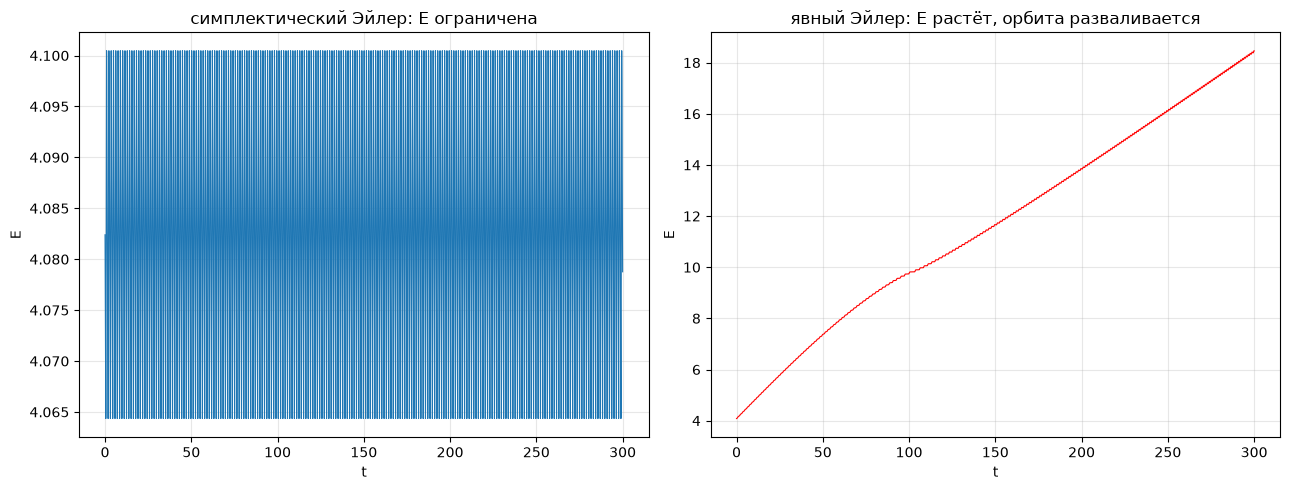

In [15]:
# энергия: симплектический vs явный Эйлер (150 периодов)
theta0, dt = 2.0, 1e-3
steps = int(300 / dt)


def energy(th, om):
    return 0.5 * l**2 * om**2 - g * l * np.cos(th)


th_s, om_s = theta0, 0.0
E_s = [energy(th_s, om_s)]
for _ in range(steps):
    om_s -= (g / l) * np.sin(th_s) * dt
    th_s += om_s * dt
    E_s.append(energy(th_s, om_s))

th_e, om_e = theta0, 0.0
E_e = [energy(th_e, om_e)]
for _ in range(steps):
    om_new = om_e - (g / l) * np.sin(th_e) * dt
    th_new = th_e + om_e * dt
    om_e, th_e = om_new, th_new
    E_e.append(energy(th_e, om_e))

t = np.linspace(0, 300, steps + 1)
print(f"симплектический: E в [{min(E_s):.6f}, {max(E_s):.6f}] "
      f"на 150 периодах (ограничена)")
print(f"явный Эйлер: E(300) = {E_e[-1]:.4f} при E(0) = {E_e[0]:.4f} "
      f"(вырождение, theta -> {th_e:.1f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t, E_s, lw=0.8)
axes[0].set_title('симплектический Эйлер: E ограничена')
axes[0].set_xlabel('t'); axes[0].set_ylabel('E'); axes[0].grid(alpha=0.3)
axes[1].plot(t, E_e, lw=0.8, color='r')
axes[1].set_title('явный Эйлер: E растёт, орбита разваливается')
axes[1].set_xlabel('t'); axes[1].set_ylabel('E'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

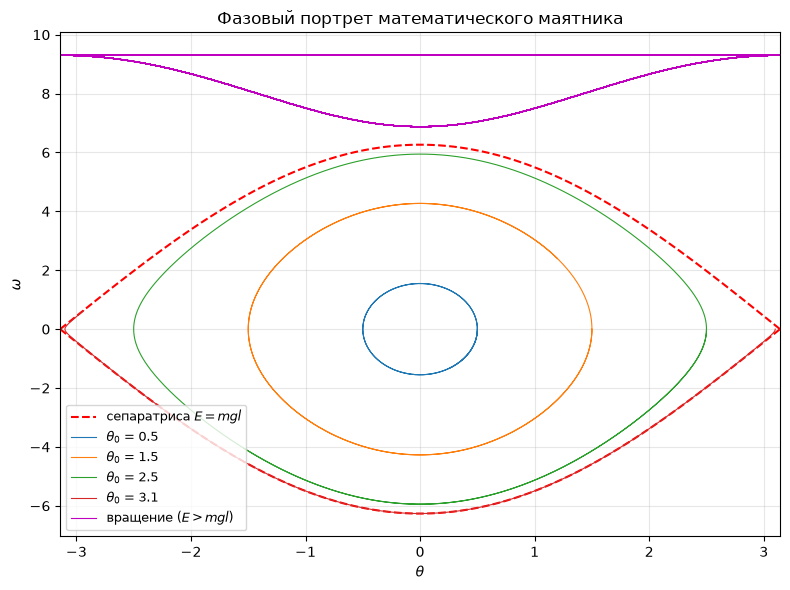

In [16]:
# фазовый портрет
def sim_phase(theta0, T, dt=2e-4):
    th, om = theta0, 0.0
    ths, oms = [th], [om]
    for _ in range(int(T / dt)):
        om -= (g / l) * np.sin(th) * dt
        th += om * dt
        ths.append(th); oms.append(om)
    return np.array(ths), np.array(oms)


fig, ax = plt.subplots(figsize=(8, 6))
ths_x = np.linspace(-np.pi, np.pi, 400)
ax.plot(ths_x, 2*np.sqrt(g/l)*np.cos(ths_x/2), 'r--', lw=1.5,
        label='сепаратриса $E = mgl$')
ax.plot(ths_x, -2*np.sqrt(g/l)*np.cos(ths_x/2), 'r--', lw=1.5)
for th0 in (0.5, 1.5, 2.5, 3.1):
    T = 4 * np.sqrt(l / g) * 3.2 if th0 > 3.0 else 2.2 * T0
    th, om = sim_phase(th0, T)
    ax.plot(th, om, lw=0.8, label=f'$\\theta_0$ = {th0}')
th, om = 0.0, 2.1 * 2 * np.sqrt(g / l) / np.sqrt(2)
ths2, oms2 = [th], [om]
for _ in range(int(6 / 2e-4)):
    om -= (g / l) * np.sin(th) * dt
    th += om * dt
    ths2.append(th); oms2.append(om)
ax.plot(np.array(ths2) % (2*np.pi) - np.pi, oms2, 'm-', lw=0.8,
        label='вращение ($E > mgl$)')
ax.set_xlim(-np.pi, np.pi)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$\omega$')
ax.set_title('Фазовый портрет математического маятника')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

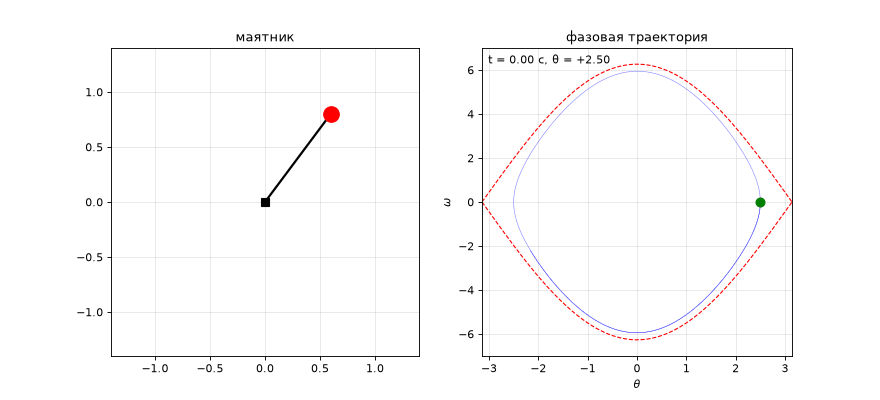

In [17]:
# анимация: маятник + фазовая точка
theta0 = 2.5
dt_anim = 2e-3
T_anim = 2.3 * T0
ths, oms = sim_phase(theta0, T_anim, dt=dt_anim)

fig = plt.figure(figsize=(11, 5), dpi=80)
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_xlim(-1.4, 1.4); ax1.set_ylim(-1.4, 1.4)
ax1.set_aspect('equal'); ax1.grid(alpha=0.3)
ax1.set_title('маятник')
rod, = ax1.plot([], [], 'k-', lw=2)
bob, = ax1.plot([], [], 'ro', ms=14)
ax1.plot(0, 0, 'ks', ms=8)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(ths_x, 2*np.sqrt(g/l)*np.cos(ths_x/2), 'r--', lw=1)
ax2.plot(ths_x, -2*np.sqrt(g/l)*np.cos(ths_x/2), 'r--', lw=1)
ax2.plot(ths, oms, 'b-', lw=0.5, alpha=0.5)
ax2.set_xlim(-np.pi, np.pi); ax2.set_ylim(-7, 7)
ax2.set_xlabel(r'$\theta$'); ax2.set_ylabel(r'$\omega$')
ax2.set_title('фазовая траектория')
ax2.grid(alpha=0.3)
ph, = ax2.plot([], [], 'go', ms=8)
txt = ax2.text(0.02, 0.95, '', transform=ax2.transAxes)


def frame35(i):
    x, y = l * np.sin(ths[i]), -l * np.cos(ths[i])
    rod.set_data([0, x], [0, y])
    bob.set_data([x], [y])
    ph.set_data([ths[i]], [oms[i]])
    txt.set_text(f't = {i*dt_anim:.2f} с, θ = {ths[i]:+.2f}')
    return rod, bob, ph, txt


save_gif(FuncAnimation(fig, frame35, frames=range(0, len(ths), 12),
                       interval=40), 'l3_5_pendulum.gif', fps=25)

**Вывод:** период маятника согласуется с эллиптическим интегралом
с точностью не хуже $10^{-8}$; гармоническое приближение ошибочно на 33%
уже при $\theta_0 = 2$; симплектический интегратор сохраняет энергию на
сотнях периодов, явный Эйлер — нет; фазовый портрет показывает
либрации, вращения и сепаратрису.